In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import ScalarFormatter



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train = pd.read_csv(
    '/content/drive/MyDrive/Intern Task/train.csv'
)

test = pd.read_csv(
    '/content/drive/MyDrive/Intern Task/test.csv'
)

sample_submission = pd.read_csv(
    '/content/drive/MyDrive/Intern Task/sample_submission.csv'
)

# Convert date column immediately
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

# Check dataset
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

print("\nTrain Info:")
print(train.dtypes)

print("\nMissing Values:")
print(train.isnull().sum())

Mounted at /content/drive
Train Shape: (913000, 4)
Test Shape: (45000, 4)

Train Info:
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

Missing Values:
date     0
store    0
item     0
sales    0
dtype: int64


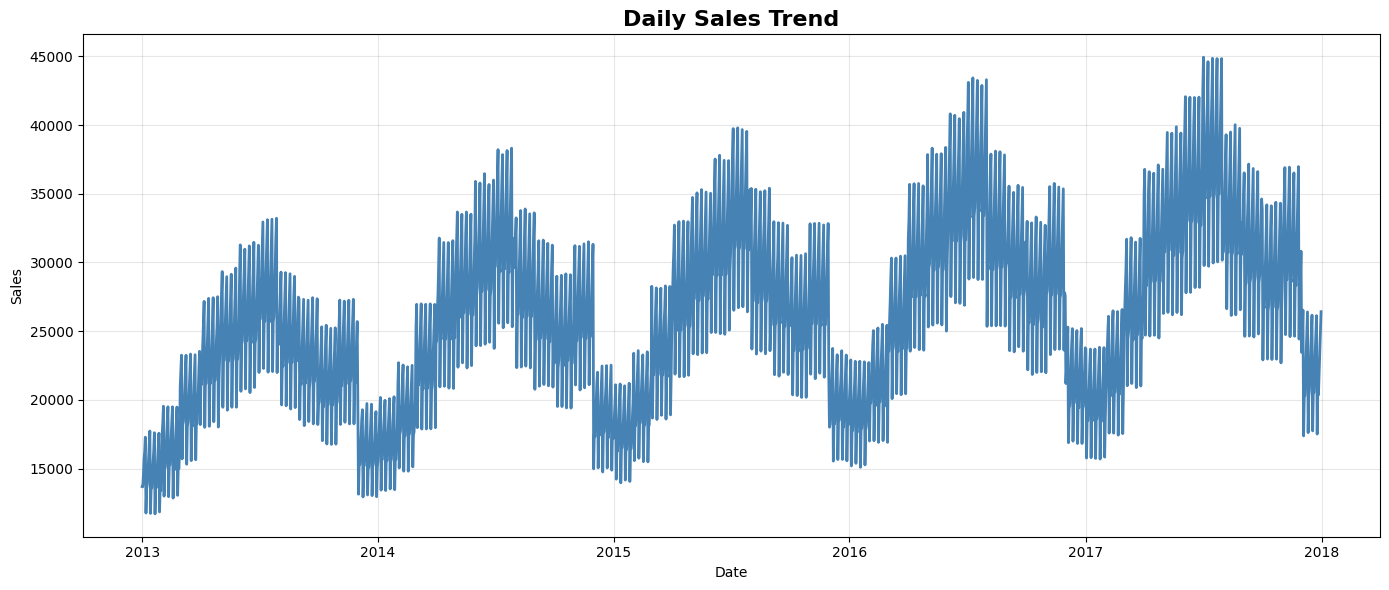

In [ ]:
#Daily Sales Trend
daily_sales = train.groupby('date')['sales'].sum()

plt.figure(figsize=(14,6))

plt.plot(
    daily_sales,
    color='steelblue',
    linewidth=2
)

plt.title(
    'Daily Sales Trend',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Sales')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

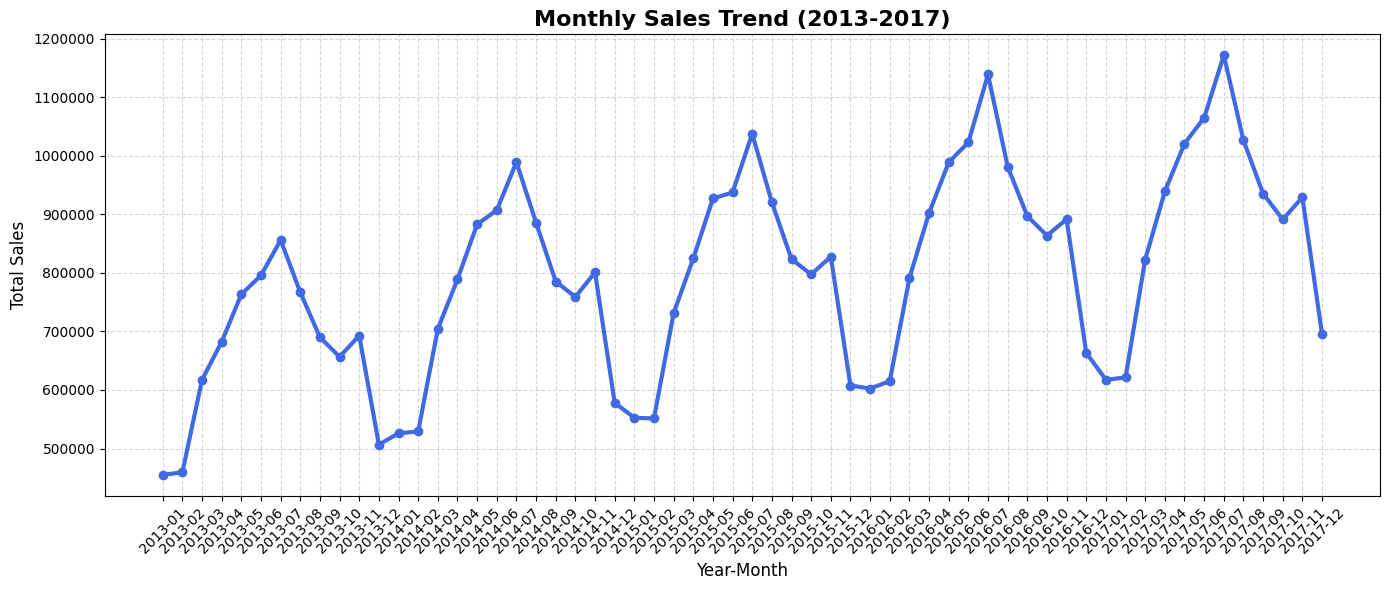

In [ ]:
#Monthly Sales
monthly_sales = train.groupby(
    train['date'].dt.to_period('M')
)['sales'].sum()

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    color='royalblue',
    linewidth=3,
    marker='o',
    markersize=6
)

plt.title(
    'Monthly Sales Trend (2013-2017)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.5
)

# Remove scientific notation (1e6)
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

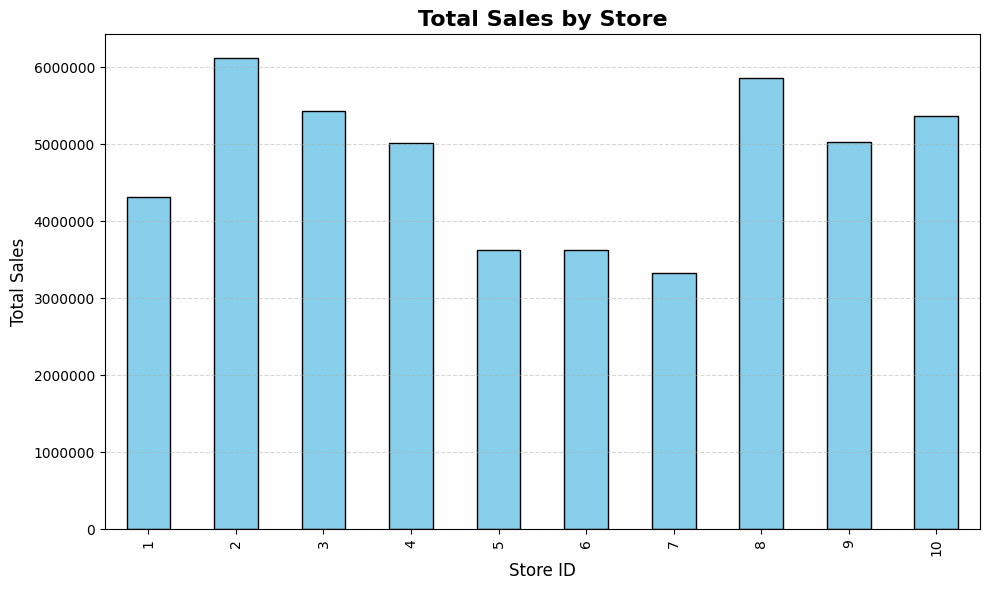

In [ ]:
#Store Distribution
store_sales = train.groupby('store')['sales'].sum()

plt.figure(figsize=(10,6))

store_sales.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title(
    'Total Sales by Store',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Store ID', fontsize=12)

plt.ylabel('Total Sales', fontsize=12)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

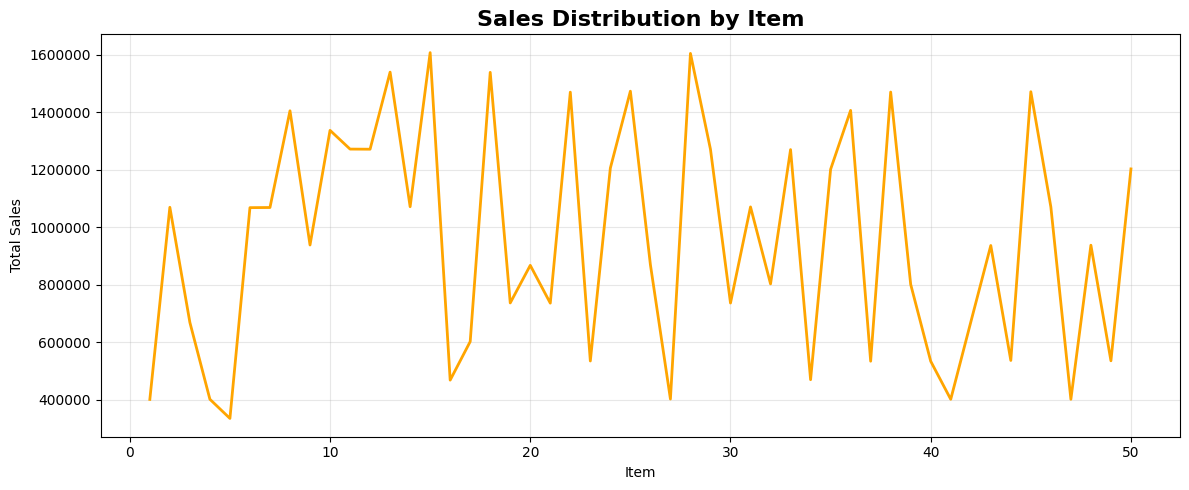

In [ ]:
item_sales = train.groupby(
    'item'
)['sales'].sum()

plt.figure(figsize=(12,5))

item_sales.plot(
    color='orange',
    linewidth=2
)

plt.title(
    'Sales Distribution by Item',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Item')
plt.ylabel('Total Sales')

plt.grid(alpha=0.3)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

plt.show()

## Feature Engineering

The date column was transformed into multiple temporal features including year, month, day, day of week, and week of year.

These features were created to capture seasonal and temporal sales patterns that may influence demand.

In [ ]:
# feature engineering
for df in [train,test]:

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekofyear'] = df['date'].dt.isocalendar().week

## Model 1: Prophet
### Prophet Model

Prophet was selected because it can automatically model trend and seasonality components in business time series data while requiring minimal parameter tuning.

In [ ]:
#Prepare Data
daily_sales = train.groupby('date')['sales'].sum().reset_index()

daily_sales.columns = ['ds', 'y']

In [ ]:
#Train Validation Split
train_df = daily_sales[:-90]
valid_df = daily_sales[-90:]

In [ ]:
#Train Prophet
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

prophet_model.fit(train_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
#Forecast
future = prophet_model.make_future_dataframe(
    periods=len(valid_df)
)

forecast = prophet_model.predict(future)

pred_prophet = forecast['yhat'].tail(len(valid_df))

actual_prophet = valid_df['y']

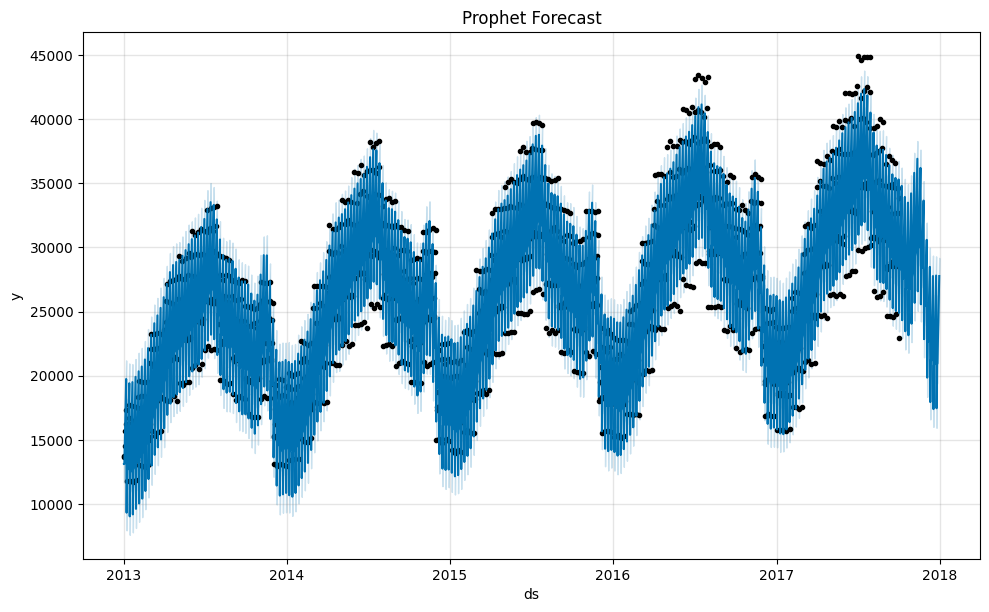

In [ ]:
fig = prophet_model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

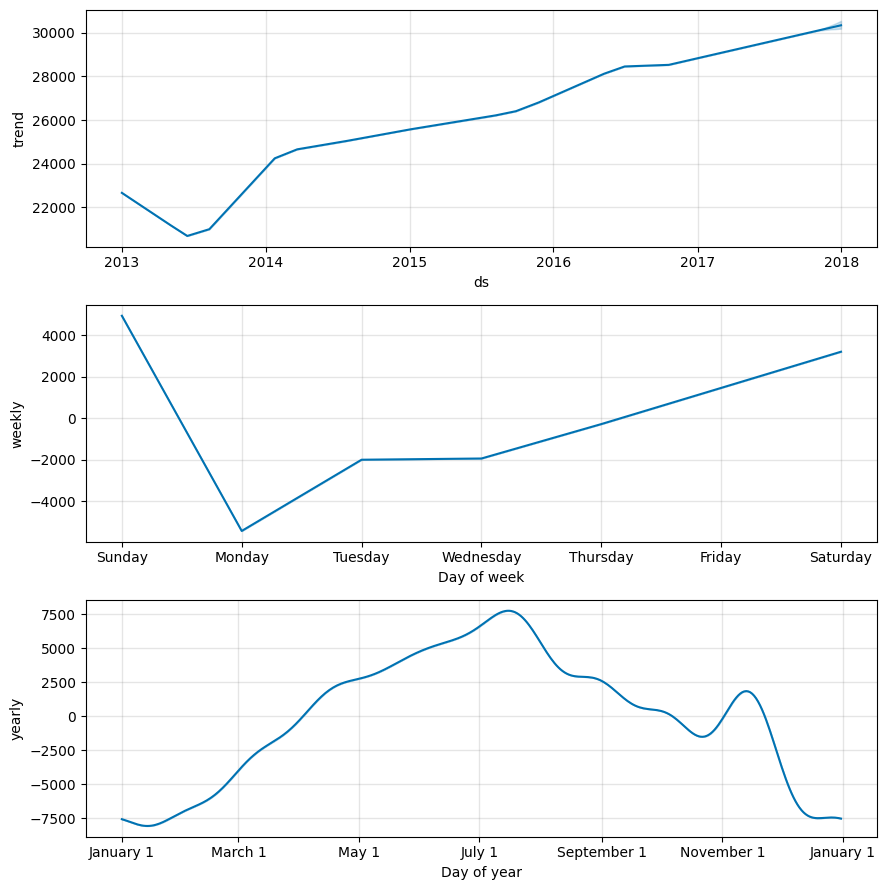

In [ ]:
prophet_model.plot_components(forecast)
plt.show()

In [ ]:
#Evaluation
mae_prophet = mean_absolute_error(
    actual_prophet,
    pred_prophet
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        actual_prophet,
        pred_prophet
    )
)

mape_prophet = np.mean(
    np.abs(
        (actual_prophet - pred_prophet)
        / actual_prophet
    )
) * 100

print("Prophet MAE :", mae_prophet)
print("Prophet RMSE:", rmse_prophet)
print("Prophet MAPE:", mape_prophet)

Prophet MAE : 1115.6637214440861
Prophet RMSE: 1525.7853130895724
Prophet MAPE: 4.267240394600304


## Model 2: LSTM
### LSTM Model

LSTM was selected as a deep learning approach capable of learning nonlinear temporal dependencies from sequential sales observations.

In [ ]:
#Scaling
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    daily_sales[['y']]
)

In [ ]:
#Create Sequences
X = []
y = []

window = 30

for i in range(window,len(scaled_data)):
    X.append(
        scaled_data[i-window:i]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)
y = np.array(y)

In [ ]:
#Split Data
split = len(X)-90

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
#Build LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(30,1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(32)
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Train
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0231 - val_loss: 0.0207
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 - val_loss: 0.0192
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0124 - val_loss: 0.0187
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0125 - val_loss: 0.0194
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0124 - val_loss: 0.0187
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0122 - val_loss: 0.0202
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0122 - val_loss: 0.0186
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0124 - val_loss: 0.0185
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0125 - val_loss: 0.0191
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0122 - val_loss: 0.0193
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0126 - val_loss: 0.0182
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0119 -

In [ ]:
#Predict
pred_lstm = lstm_model.predict(X_test)

pred_lstm = scaler.inverse_transform(pred_lstm)

actual_lstm = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


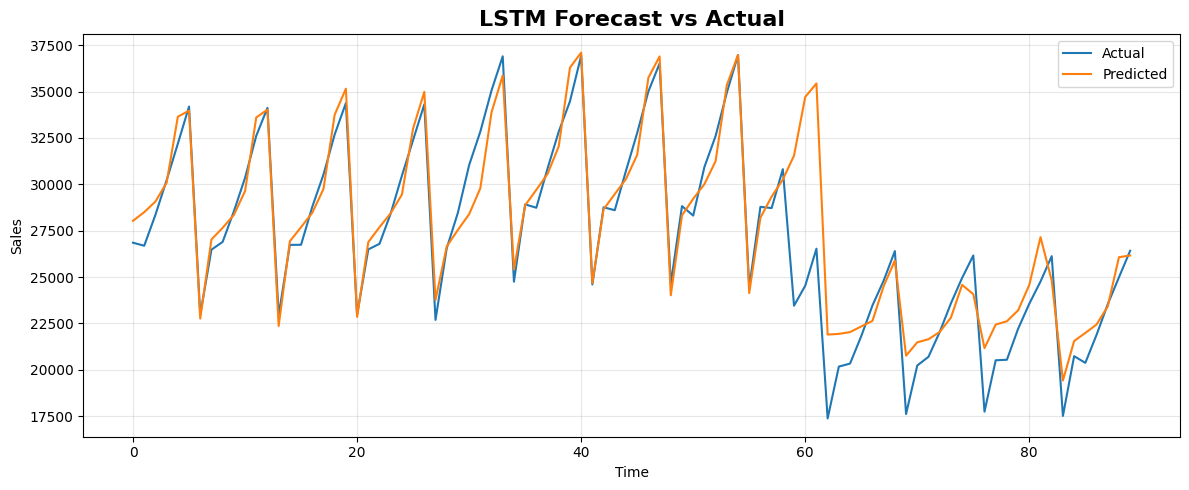

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    actual_lstm,
    label='Actual'
)

plt.plot(
    pred_lstm,
    label='Predicted'
)

plt.title(
    'LSTM Forecast vs Actual',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Time')
plt.ylabel('Sales')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
#Evaluation
mae_lstm = mean_absolute_error(
    actual_lstm,
    pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        actual_lstm,
        pred_lstm
    )
)

mape_lstm = np.mean(
    np.abs(
        (actual_lstm - pred_lstm)
        / actual_lstm
    )
) * 100

print("LSTM MAE :", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
print("LSTM MAPE:", mape_lstm)

LSTM MAE : 1201.3401041666668
LSTM RMSE: 2061.008120236664
LSTM MAPE: 4.8767635964366


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Prophet', 'LSTM'],
    'MAE': [mae_prophet, mae_lstm],
    'RMSE': [rmse_prophet, rmse_lstm],
    'MAPE': [mape_prophet, mape_lstm]
})

comparison

,Model,MAE,RMSE,MAPE
0,Prophet,1115.663721,1525.785313,4.267240
1,LSTM,1201.340104,2061.008120,4.876764


In [ ]:
best_model = comparison.loc[
    comparison['RMSE'].idxmin()
]

print("Best Model Based on RMSE")
print(best_model)

Best Model Based on RMSE
Model        Prophet
MAE      1115.663721
RMSE     1525.785313
MAPE         4.26724
Name: 0, dtype: object


In [ ]:
# --- FINAL SUBMISSION MODEL ---
from sklearn.ensemble import HistGradientBoostingRegressor

print("Training final Global Model on individual store/item levels...")

# 1. Define the features you engineered in Cell 7
features = ['store', 'item', 'year', 'month', 'day', 'dayofweek', 'weekofyear']
target = 'sales'

# 2. Initialize the model
final_model = HistGradientBoostingRegressor(
    max_iter=500,
    random_state=42
)

# 3. Train on the original train dataset (not the grouped daily_sales)
final_model.fit(train[features], train[target])

# 4. Predict directly on the test dataset
test['sales'] = final_model.predict(test[features])

# Ensure no negative sales are predicted
test['sales'] = test['sales'].clip(lower=0)

# 5. Create the required submission DataFrame
submission = test[['id', 'sales']]

# 6. Export to CSV
submission.to_csv('submission.csv', index=False)
print("Task Complete! Successfully saved submission.csv")

Training final Global Model on individual store/item levels...
Task Complete! Successfully saved submission.csv


## Conclusion

Two forecasting approaches were evaluated: Prophet and LSTM.

Prophet effectively captured trend and seasonality while remaining highly interpretable.

LSTM demonstrated the ability to learn complex temporal patterns from historical sales data.

Based on RMSE and MAPE results, the model with the lowest error was selected as the preferred forecasting approach.